# Top n nucleotide LFC signal region distribution  
add an enrichment plot?

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patches as patches
from matplotlib.ticker import ScalarFormatter
from matplotlib.path import Path
from matplotlib.patches import PathPatch, Patch
from matplotlib.ticker import PercentFormatter
import numpy as np
import seaborn as sns
from Bio import SeqIO
import warnings
warnings.filterwarnings("ignore")
import re
import pyranges as pr
import math
import matplotlib as mpl
from matplotlib import font_manager

arial_path = "/media/scratch/fy2306/tools/fonts"
font_files = font_manager.findSystemFonts(fontpaths=arial_path)

for file in font_files:
    font_manager.fontManager.addfont(file)
    
mpl.rcParams['font.family'] = 'Arial'

In [5]:
id_prefix_list = [
	"MYC_GFP_"
]

In [6]:
# remove negative controls that can be mapped to the genome (with bowtie)
mapped_ctrl_path = "/media/scratch/fy2306/projects/base_editing/data/bowtie/all/all_sgrna_seqs.bowtie_hg38.mismatch1.processed.tsv"
mapped_ctrl_df = pd.read_csv(mapped_ctrl_path, sep="\t")
mapped_ctrl_df = mapped_ctrl_df[
    mapped_ctrl_df['id'].str.startswith(('Random', 'Non-targeting-controls', 'AAVS1'))
    & ~(mapped_ctrl_df['id'].str.startswith('AAVS1') & (mapped_ctrl_df['Alignments_NM0'] == 1) & (mapped_ctrl_df['Alignments_NM1'] == 0))
]
mapped_ctrl_list = mapped_ctrl_df["id"].tolist()
print(len(mapped_ctrl_list))
all_ctrl = [
    record.id for record in SeqIO.parse("/media/scratch/fy2306/projects/base_editing/data/bowtie/negative_controls/input/negative_controls.fa", "fasta")
    ]
clean_ctrl_list = list(set(all_ctrl)-set(mapped_ctrl_list))
print(len(clean_ctrl_list))
print(len(all_ctrl))

91
474
565


In [7]:
# randomly group nc sgrnas
def group_and_aggregate(df, group_size, cons_col, random_state=None):
    df_shuffled = df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    
    num_groups = len(df_shuffled) // group_size
    df_trimmed = df_shuffled.iloc[:num_groups * group_size]
    
    grouped = np.array_split(df_trimmed, num_groups)
    
    aggregated = []
    for group in grouped:
        sgrna_concat = ','.join(group['sgrna'].astype(str))
        avg_lfc = group['per time unit LFC'].mean()
        cons_val = group[cons_col].iloc[0]
        aggregated.append({
            'sgrna': sgrna_concat,
            'per time unit LFC': avg_lfc,
            cons_col: cons_val
        })
    
    return pd.DataFrame(aggregated)

In [8]:
def top_select_pie(
		gene, myc_var, edited_pos_chr_col, treatment_col,
		date,
		test_name,
		nc_test_name,
		merge_method_nucleotide, 
		win_size,
		baseline,
		treatments,
		day_numbers,
		merge_method_replicate,
		top_direction,
		top_percentage, 
		per_time_unit=True,
        legend=False):
	
	# process the cutting site
	df_myc_path = f"/media/scratch/fy2306/projects/base_editing/data/{date}/mageck/{test_name}/{merge_method_nucleotide}/myc_repeats/{win_size}/MYC_U1.gene_summary.txt"
	df_myc = pd.read_csv(df_myc_path, sep="\t")
	pattern = f"^({'|'.join(map(re.escape, id_prefix_list))})([0-9]*\.?[0-9]+)"
	df_myc = df_myc[df_myc['id'].str.match(pattern)]
	df_myc[edited_pos_chr_col] = df_myc['id'].str.extract(pattern)[1].astype(int)

	# merge
	treatment_lfc_columns = [f"{treatment}_vs_{baseline}|neg|lfc" for treatment in treatments]

	if per_time_unit:
		for col, day in zip(treatment_lfc_columns, day_numbers):
			df_myc[col] = df_myc[col] / (day + 0) # per time unit.

	if merge_method_replicate == "mean":
		df_myc["per time unit LFC"] = df_myc[treatment_lfc_columns].mean(axis=1)
	df_myc = df_myc[['id', 'per time unit LFC', edited_pos_chr_col]]
	# columns: id, per time unit LFC, edited_pos_chr_col

	# load in lib to add cons col
	cons_col = treatment_col + "_consequences"

	lib_path = f"/media/scratch/fy2306/projects/base_editing/data/grna_type/MYC-lib-for-mageck.type.{myc_var}.organized.txt"
	df_lib = pd.read_csv(lib_path, sep="\t", usecols=[edited_pos_chr_col, cons_col])
	df_lib = df_lib.drop_duplicates(subset=edited_pos_chr_col)
	df_myc = pd.merge(df_myc, df_lib, on=edited_pos_chr_col, how='left')

	# add repeats
	rmsk_path = "/media/dna/fy2306/genomes/hg38/RepeatMasker/rmsk.txt"
	rmsk_colnames = ["bin", "swScore", "milliDiv", "milliDel", "milliIns", "genoName", "genoStart", "genoEnd", "genoLeft", "strand", "repName", "repClass", "repFamily", "repStart", "repEnd", "repLeft", "id"]
	rmsk = pd.read_csv(rmsk_path, sep="\t", header=None, names=rmsk_colnames)
	rmsk = rmsk[rmsk['genoName'] == "chr8"]
	# rmsk: 0-based
	rmsk_ranges = pr.PyRanges(rmsk.rename(columns={
	'genoName': 'Chromosome',
	'genoStart': 'Start',
	'genoEnd': 'End'
	}))

	# base_pos: 1-based
	df_myc['Start'] = df_myc[edited_pos_chr_col] - 1
	df_myc['End'] = df_myc['Start'] + 1
	df_myc['Chromosome'] = 'chr8'

	df_myc["orig_index"] = df_myc.index
	df_ranges = pr.PyRanges(df_myc[['Chromosome', 'Start', 'End', 'orig_index']])

	overlap = df_ranges.intersect(rmsk_ranges, how="containment")	# in pyranges: “containment” reports intervals where the overlapping is contained within it, gives you the intervals in self be completely within the intervals in other
	overlap_indices = overlap.df['orig_index'].unique()

	df_myc["indel_repeats"] = False
	df_myc.loc[overlap_indices, "indel_repeats"] = True

	# degenerate cons
	df_myc = df_myc[df_myc["indel_repeats"] == False]	# remove repeats
	df_myc.loc[
		df_myc[cons_col].isin(['3_prime_UTR', 'downstream_flanking']),
		cons_col
	] = '3_prime_UTR \n + downstream_flanking'
	df_myc.loc[
		df_myc[cons_col].isin(['5_prime_UTR', 'upstream_flanking']),
		cons_col
	] = '5_prime_UTR \n + upstream_flanking'
	df_myc.loc[df_myc[cons_col] == "intron_splice", cons_col] = 'intron'
	df_myc["coding"] = ["coding" if x == 'coding' else "non-coding" for x in df_myc[cons_col]]

	# process the negative controls
	df_nc = None
	for treatment in treatments:
		df_nc_path = f"/media/scratch/fy2306/projects/base_editing/data/{date}/mageck/{nc_test_name}/MYC_U1.{treatment}_vs_{baseline}.sgrna_summary.txt"
		df_nc_rep = pd.read_csv(df_nc_path, sep="\t", usecols=["sgrna", "Gene", "LFC"])
		df_nc_rep = df_nc_rep[df_nc_rep["Gene"].isin(["AAVS1", "NT", "Random"])]
		df_nc_rep = df_nc_rep.drop('Gene', axis=1)
		df_nc_rep = df_nc_rep.rename(columns={"LFC": f"LFC_{treatment}"})
		if df_nc is None:
			df_nc = df_nc_rep
		else:
			# Merge on 'sgrna'
			df_nc = pd.merge(df_nc, df_nc_rep, on="sgrna", how="inner")
	print(len(df_nc))

	treatment_lfc_nc_columns = [f"LFC_{treatment}" for treatment in treatments]

	if per_time_unit:
		for col, day in zip(treatment_lfc_nc_columns, day_numbers):
			df_nc[col] = df_nc[col] / (day + 0) # per time unit.

	if merge_method_replicate == "mean":
		df_nc["per time unit LFC"] = df_nc[treatment_lfc_nc_columns].mean(axis=1)

	# remove mismatches
	df_nc = df_nc[~(df_nc["sgrna"].isin(mapped_ctrl_list))]
	df_nc[cons_col] = "negative_controls"
	df_nc = df_nc[['sgrna', 'per time unit LFC', cons_col]]
	# columns: sgrna, per time unit LFC, cons_col

	# random group of df_nc
	n_repeats = 1000
	all_results = []

	for seed in range(n_repeats):
		df_nc_result = group_and_aggregate(df_nc, group_size=2*int(win_size), cons_col=cons_col, random_state=seed)
		all_results.append(df_nc_result)

	df_nc_combined = pd.concat(all_results, ignore_index=True)
	nc_combined_median_value = df_nc_combined["per time unit LFC"].median()
	print(nc_combined_median_value)

	# shift according to nc
	df_myc["per time unit LFC"] = df_myc["per time unit LFC"] - nc_combined_median_value
	print(len(df_myc))

	# Select top
	if top_direction == "pos":
		df_myc["score"] = df_myc["per time unit LFC"]           # most positive first
		ascending = False
	elif top_direction == "neg":
		df_myc["score"] = df_myc["per time unit LFC"]           # most negative first
		ascending = True
	elif top_direction == "abs":
		df_myc["score"] = df_myc["per time unit LFC"].abs()     # absolute effect first
		ascending = False

	n =  math.ceil(len(df_myc) * float(top_percentage))
	df_top = df_myc.sort_values("score", ascending=ascending).head(n)

	# pie chart
	counts = df_top[cons_col].value_counts()

	# pie chart
	fig, ax = plt.subplots(figsize=(4, 4))
	color_map = {
    "intron": "#AA66FF",
    "5_prime_UTR \n + upstream_flanking": "#107F80",
    "3_prime_UTR \n + downstream_flanking": "#66CCFE",
    "coding": "#FF0066"
	}

	colors = [color_map[g] for g in counts.index]
	wedges, texts = ax.pie(
		counts.values,
		colors=colors,
		startangle=90,
		wedgeprops={"linewidth": 1, "edgecolor": "white"},
	)

	total = sum(counts.values)
	for i, wedge in enumerate(wedges):
		ang = (wedge.theta2 + wedge.theta1) / 2  # midpoint angle of slice
		x = np.cos(np.deg2rad(ang))
		y = np.sin(np.deg2rad(ang))

		ax.annotate(
			f"{counts.values[i]/total*100:.1f}%",
			xy=(x, y),
			xytext=(1.3 * x, 1.3 * y),  
			ha="center", va="center",
			fontsize=12,
			arrowprops=dict(arrowstyle="-", color="black")  
		)
	plt.title(f"Top {int(top_percentage*100)}% nucleotides by LFC {top_direction} direction \n N={n}", fontsize=13, pad=15)
	plt.tight_layout()
	plt.show()
    
	if legend:
		handles = [
			mpatches.Patch(color=color_map[g], label=g) 
			for g in counts.index
		]

		fig, ax = plt.subplots()
		ax.legend(
			handles=handles,
			loc="center",
			fontsize=12,
			frameon=False
		)
		ax.axis("off")
		plt.show()

In [9]:
def top_select_bar(
		gene, myc_var, edited_pos_chr_col, treatment_col,
		date,
		test_name,
		nc_test_name,
		merge_method_nucleotide, 
		win_size,
		baseline,
		treatments,
		day_numbers,
		merge_method_replicate,
		top_percentage, 
		per_time_unit=True):

	# process the cutting site
	df_myc_path = f"/media/scratch/fy2306/projects/base_editing/data/{date}/mageck/{test_name}/{merge_method_nucleotide}/myc_repeats/{win_size}/MYC_U1.gene_summary.txt"
	df_myc = pd.read_csv(df_myc_path, sep="\t")
	pattern = f"^({'|'.join(map(re.escape, id_prefix_list))})([0-9]*\.?[0-9]+)"
	df_myc = df_myc[df_myc['id'].str.match(pattern)]
	df_myc[edited_pos_chr_col] = df_myc['id'].str.extract(pattern)[1].astype(int)

	# merge
	treatment_lfc_columns = [f"{treatment}_vs_{baseline}|neg|lfc" for treatment in treatments]
	treatment_fdr_columns = [f"{treatment}_vs_{baseline}|neg|fdr" for treatment in treatments]
	treatment_fdr_goodsgrna_columns = [f"{treatment}_vs_{baseline}|neg|goodsgrna" for treatment in treatments]
	treatment_fdr_pos_columns = [f"{treatment}_vs_{baseline}|pos|fdr" for treatment in treatments]
	treatment_fdr_pos_goodsgrna_columns = [f"{treatment}_vs_{baseline}|pos|goodsgrna" for treatment in treatments]
	if per_time_unit:
		for col, day in zip(treatment_lfc_columns, day_numbers):
			df_myc[col] = df_myc[col] / (day + 0) # per time unit.

	if merge_method_replicate == "mean":
		df_myc["per time unit LFC"] = df_myc[treatment_lfc_columns].mean(axis=1)
	# copied from lfc_to_seq
	for fdr_col, goodsgrna_col in zip(treatment_fdr_columns, treatment_fdr_goodsgrna_columns):
		df_myc.loc[df_myc[goodsgrna_col] < 2, fdr_col] = 1
	df_myc["neg|fdr"] = df_myc[treatment_fdr_columns].apply(lambda row: sorted(row)[1], axis=1)	# second-lowest fdr
	df_myc["direction"] = df_myc[treatment_lfc_columns].apply(lambda row: (row.gt(0).all() or row.lt(0).all()), axis=1)
	for fdr_col, goodsgrna_col in zip(treatment_fdr_pos_columns, treatment_fdr_pos_goodsgrna_columns):
		df_myc.loc[df_myc[goodsgrna_col] < 2, fdr_col] = 1
	df_myc["pos|fdr"] = df_myc[treatment_fdr_pos_columns].apply(lambda row: sorted(row)[1], axis=1)	# second-lowest fdr
	df_myc["fdr"] = df_myc[["neg|fdr", "pos|fdr"]].min(axis=1)
	df_myc = df_myc[['id', 'per time unit LFC', edited_pos_chr_col, 'fdr', 'direction']]
	# columns: id, per time unit LFC, edited_pos_chr_col

	# load in lib to add cons col
	cons_col = treatment_col + "_consequences"

	lib_path = f"/media/scratch/fy2306/projects/base_editing/data/grna_type/MYC-lib-for-mageck.type.{myc_var}.organized.txt"
	df_lib = pd.read_csv(lib_path, sep="\t", usecols=[edited_pos_chr_col, cons_col])
	df_lib = df_lib.drop_duplicates(subset=edited_pos_chr_col)
	df_myc = pd.merge(df_myc, df_lib, on=edited_pos_chr_col, how='left')

	# add repeats
	rmsk_path = "/media/dna/fy2306/genomes/hg38/RepeatMasker/rmsk.txt"
	rmsk_colnames = ["bin", "swScore", "milliDiv", "milliDel", "milliIns", "genoName", "genoStart", "genoEnd", "genoLeft", "strand", "repName", "repClass", "repFamily", "repStart", "repEnd", "repLeft", "id"]
	rmsk = pd.read_csv(rmsk_path, sep="\t", header=None, names=rmsk_colnames)
	rmsk = rmsk[rmsk['genoName'] == "chr8"]
	# rmsk: 0-based
	rmsk_ranges = pr.PyRanges(rmsk.rename(columns={
	'genoName': 'Chromosome',
	'genoStart': 'Start',
	'genoEnd': 'End'
	}))

	# base_pos: 1-based
	df_myc['Start'] = df_myc[edited_pos_chr_col] - 1
	df_myc['End'] = df_myc['Start'] + 1
	df_myc['Chromosome'] = 'chr8'

	df_myc["orig_index"] = df_myc.index
	df_ranges = pr.PyRanges(df_myc[['Chromosome', 'Start', 'End', 'orig_index']])

	overlap = df_ranges.intersect(rmsk_ranges, how="containment")	# in pyranges: “containment” reports intervals where the overlapping is contained within it, gives you the intervals in self be completely within the intervals in other
	overlap_indices = overlap.df['orig_index'].unique()

	df_myc["indel_repeats"] = False
	df_myc.loc[overlap_indices, "indel_repeats"] = True

	# degenerate cons
	# df_myc.loc[
	# 	df_myc[cons_col].isin(['3_prime_UTR', 'downstream_flanking']),
	# 	cons_col
	# ] = '3_prime_UTR \n + downstream_flanking'
	# df_myc.loc[
	# 	df_myc[cons_col].isin(['5_prime_UTR', 'upstream_flanking']),
	# 	cons_col
	# ] = '5_prime_UTR \n + upstream_flanking'
	df_myc.loc[df_myc[cons_col] == "intron_splice", cons_col] = 'intron'
	df_myc["coding"] = ["coding" if x == 'coding' else "non-coding" for x in df_myc[cons_col]]

	# process the negative controls
	df_nc = None
	for treatment in treatments:
		df_nc_path = f"/media/scratch/fy2306/projects/base_editing/data/{date}/mageck/{nc_test_name}/MYC_U1.{treatment}_vs_{baseline}.sgrna_summary.txt"
		df_nc_rep = pd.read_csv(df_nc_path, sep="\t", usecols=["sgrna", "Gene", "LFC"])
		df_nc_rep = df_nc_rep[df_nc_rep["Gene"].isin(["AAVS1", "NT", "Random"])]
		df_nc_rep = df_nc_rep.drop('Gene', axis=1)
		df_nc_rep = df_nc_rep.rename(columns={"LFC": f"LFC_{treatment}"})
		if df_nc is None:
			df_nc = df_nc_rep
		else:
			# Merge on 'sgrna'
			df_nc = pd.merge(df_nc, df_nc_rep, on="sgrna", how="inner")
	print(len(df_nc))

	treatment_lfc_nc_columns = [f"LFC_{treatment}" for treatment in treatments]

	if per_time_unit:
		for col, day in zip(treatment_lfc_nc_columns, day_numbers):
			df_nc[col] = df_nc[col] / (day + 0) # per time unit.

	if merge_method_replicate == "mean":
		df_nc["per time unit LFC"] = df_nc[treatment_lfc_nc_columns].mean(axis=1)

	# remove mismatches
	df_nc = df_nc[~(df_nc["sgrna"].isin(mapped_ctrl_list))]
	df_nc[cons_col] = "negative_controls"
	df_nc = df_nc[['sgrna', 'per time unit LFC', cons_col]]
	# columns: sgrna, per time unit LFC, cons_col

	# random group of df_nc
	n_repeats = 1000
	all_results = []

	for seed in range(n_repeats):
		df_nc_result = group_and_aggregate(df_nc, group_size=2*int(win_size), cons_col=cons_col, random_state=seed)
		all_results.append(df_nc_result)

	df_nc_combined = pd.concat(all_results, ignore_index=True)
	nc_combined_median_value = df_nc_combined["per time unit LFC"].median()
	print(nc_combined_median_value)

	# shift according to nc
	df_myc["per time unit LFC"] = df_myc["per time unit LFC"] - nc_combined_median_value
	print(len(df_myc))
	print(df_myc[df_myc[edited_pos_chr_col] == 127741050])

	# filter: remove repeats, separate promoter region
	df_myc = df_myc[df_myc["indel_repeats"] == False]	# remove repeats
	print(len(df_myc))
	df_myc.loc[
		(df_myc[edited_pos_chr_col] >= (127736084-1000)) & (df_myc[cons_col] == 'upstream_flanking'),
		cons_col
		] = 'promoter'
	df_myc.loc[
		df_myc[cons_col].isin(['upstream_flanking', 'downstream_flanking']),
		cons_col
		] = 'intergenic'
	print(df_myc[cons_col].value_counts())

	# top select
	n = math.ceil(len(df_myc) * float(top_percentage))

	df_all = df_myc
	df_sig = df_myc[(df_myc['fdr'] < 0.05) & (df_myc['direction'] == True)]	# add: sig nucleotides (as in lfc_to_seq plot)
	# stats to show the activating 5'half
	n1 = len(df_myc[(df_myc['fdr'] < 0.05) & (df_myc['direction'] == True) & (df_myc[cons_col] != 'coding')])	# number of noncoding sig bp
	n2 = len(df_myc[(df_myc['fdr'] < 0.05) & (df_myc['direction'] == True) & (df_myc[cons_col] != 'coding') & (df_myc[edited_pos_chr_col] < 127738263)])	# number of noncoding sig bp in 5' half (splitting by the cds start in exon 2)
	print(f"Noncoding sig bp in 5' half: {n2}/{n1} = {n2/n1*100:.2f}%")
	df_abs = df_myc.assign(score=df_myc["per time unit LFC"].abs()).sort_values("score", ascending=False).head(n)
	# df_neg = df_myc.assign(score=df_myc["per time unit LFC"]).sort_values("score", ascending=True).head(n)
	# print(df_neg["per time unit LFC"].max())	# should be negative
	# df_pos = df_myc.assign(score=df_myc["per time unit LFC"]).sort_values("score", ascending=False).head(n)
	# print(df_pos["per time unit LFC"].min())	# should be positive

	stages = [
		(f"All\n(N = {len(df_all)})",   df_all),
		(f"Sig\n(N = {len(df_sig)})",   df_sig),
		(f"Abs {int(top_percentage*100)}%\n(N = {len(df_abs)})",   df_abs),
		# (f"Neg {int(top_percentage*100)}%",   df_neg),
		# (f"Pos {int(top_percentage*100)}%",   df_pos),
	]

	# stats needed
	print(f"Non-coding sig bps: {len(df_sig[df_sig[cons_col] != 'coding'])}")
	print(f"Non-coding sig bps upstream of 127738759: {len(df_sig[(df_sig[cons_col] != 'coding') & (df_sig[edited_pos_chr_col] < 127738759)])}")	# splitting by the middle of intron 2
	print(f"Pct: {len(df_sig[(df_sig[cons_col] != 'coding') & (df_sig[edited_pos_chr_col] < 127738759)]) / len(df_sig[df_sig[cons_col] != 'coding']) * 100:.2f}%")

	color_map = {
	"intergenic": "#c4a46f",
	"3_prime_UTR": "#93ad57",
	"intron": "#419554",
    "5_prime_UTR": "#286d7d",
	"promoter": "#080b75",
	"coding": "#FF0066"
	}
	cats = list(color_map.keys())

	# proportions for each stage
	props = {}
	for name, d in stages:
		counts = d[cons_col].value_counts().reindex(cats, fill_value=0)
		props[name] = (counts / counts.sum()).fillna(0)

	# cumulative spans
	spans = {}
	for name in props:
		y = 0.0
		spans[name] = {}
		for c in cats:
			h = float(props[name].loc[c])
			spans[name][c] = (y, y + h)
			y += h

	fig, ax = plt.subplots(figsize=(4, 5))
	bar_width = 0.6
	ribbon_alpha = 0.40

	xs = np.arange(len(stages))
	ax.set_xlim(-0.5, len(stages)-0.5)
	ax.set_ylim(0, 1)

	def add_ribbon(x0, y0a, y0b, x1, y1a, y1b, facecolor, alpha):
		# straight-sided polygon: (x0,y0a)→(x1,y1a)→(x1,y1b)→(x0,y0b)→close
		verts = [
			(x0, y0a),
			(x1, y1a),
			(x1, y1b),
			(x0, y0b),
			(x0, y0a),  # close
		]
		codes = [
			Path.MOVETO,
			Path.LINETO, Path.LINETO, Path.LINETO,
			Path.CLOSEPOLY,
		]
		patch = PathPatch(Path(verts, codes),
						facecolor=facecolor, edgecolor="none",
						alpha=alpha, zorder=1)
		ax.add_patch(patch)

	# ribbons
	for i in range(len(stages)-1):
		s0, _ = stages[i]
		s1, _ = stages[i+1]
		x0 = xs[i] + bar_width/2
		x1 = xs[i+1] - bar_width/2
		for c in cats:
			y0a, y0b = spans[s0][c]
			y1a, y1b = spans[s1][c]
			if (y0b - y0a) == 0 and (y1b - y1a) == 0:
				continue
			add_ribbon(x0, y0a, y0b, x1, y1a, y1b, color_map[c], ribbon_alpha)

	# stacked bars + labels
	for i, (name, _) in enumerate(stages):
		bottom = 0.0
		for c in cats:
			h = float(props[name].loc[c])
			if h == 0:
				continue
			ax.bar(xs[i], h, width=bar_width, bottom=bottom,
				color=color_map[c], edgecolor="white", linewidth=0.8, zorder=2)
			if h > 0.03:  # show only if >3%
				y0, y1 = spans[name][c]
				ymid = (y0+y1)/2
				ax.text(xs[i], ymid, r"$\mathbf{" + f"{h*100:.0f}" + r"\%}$", ha="center", va="center",
						color="white", fontsize=12, zorder=3)
			bottom += h

	ax.set_xticks(xs)
	ax.set_xticklabels([name for name, _ in stages])
	ax.yaxis.set_major_formatter(PercentFormatter(1.0))
	ax.set_ylabel("Percentage", fontsize=14)
	ax.tick_params(axis='both', labelsize=14)
	sns.despine(ax=ax, left=False, bottom=False)

	plt.tight_layout()
	plt.savefig("/media/scratch/fy2306/projects/base_editing/plots/screening/top_basepair_category.pdf", 
				bbox_inches="tight",
				dpi=300,              
				transparent=True,
				format='pdf')
	plt.show()

	handles = [
		mpatches.Patch(color=color_map[g], label=g) 
		for g in counts.index
	]

	fig, ax = plt.subplots()
	ax.legend(
		handles=handles,
		loc="center",
		fontsize=12,
		frameon=False,
		ncol=2
	)
	ax.axis("off")
	plt.savefig("/media/scratch/fy2306/projects/base_editing/plots/screening/top_basepair_category.legend.pdf", 
				bbox_inches="tight",
				dpi=300,              
				transparent=True,
				format='pdf')
	plt.show()

565
-0.0028773212890625005
10055
                     id  per time unit LFC  indel_base_pos_chr      fdr  \
1211  MYC_GFP_127741050          -0.039894           127741050  0.20216   

      direction indel_consequences      Start        End Chromosome  \
1211       True        3_prime_UTR  127741049  127741050       chr8   

      orig_index  indel_repeats      coding  
1211        1211          False  non-coding  
9225
indel_consequences
intergenic     3350
intron         2690
coding         1266
promoter        948
5_prime_UTR     493
3_prime_UTR     476
Name: count, dtype: int64
Noncoding sig bp in 5' half: 195/231 = 84.42%
Non-coding sig bps: 231
Non-coding sig bps upstream of 127738759: 195
Pct: 84.42%


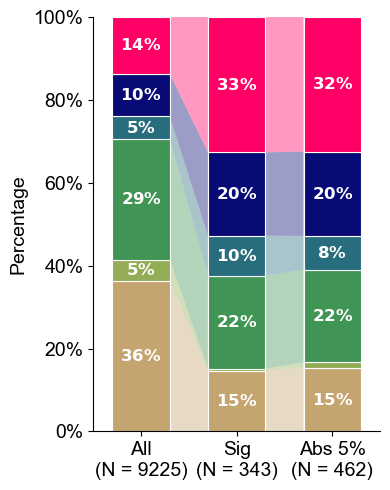

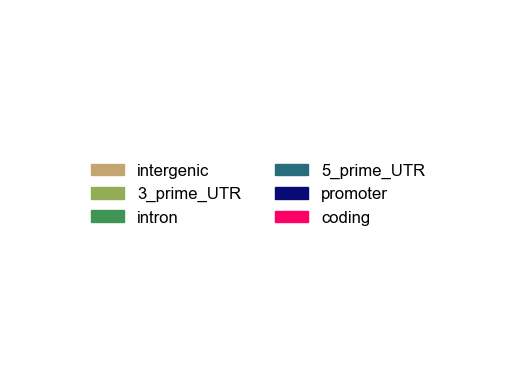

In [10]:
gene = "MYC-wt"
myc_var = "myc2_indel"
edited_pos_chr_col = "indel_base_pos_chr"
treatment_col = "indel"
date = "20250416"
test_name = "test-1-standard-nucleotide/test"
nc_test_name = "test-1-standard/test"
merge_method_nucleotide = "mean"
win_size = "4"
baseline = "Cas9-HMOI_D0"
treatments = ["Cas9-LMOI_D20", "Cas9-LMOI_D8", "Cas9_SpRY_L_MOI_D_20", "Cas9_SpRY_L_MOI_D_8"]
day_numbers = [20, 8, 20, 8]
merge_method_replicate = "mean"
top_direction = "neg"
top_percentage = 0.05
# top_select_pie(
# 		gene, myc_var, edited_pos_chr_col, treatment_col,
# 		date,
# 		test_name,
# 		nc_test_name,
# 		merge_method_nucleotide, 
# 		win_size,
# 		baseline,
# 		treatments,
# 		day_numbers,
# 		merge_method_replicate,
# 		top_direction,
# 		top_percentage, 
# 		per_time_unit=True,
#         legend=True)
top_select_bar(
		gene, myc_var, edited_pos_chr_col, treatment_col,
		date,
		test_name,
		nc_test_name,
		merge_method_nucleotide, 
		win_size,
		baseline,
		treatments,
		day_numbers,
		merge_method_replicate,
		top_percentage, 
		per_time_unit=True)